In [1]:
# ==============================================================================
# ЯЧЕЙКА 1: ИМПОРТЫ И ПОДГОТОВКА ДАННЫХ (ВЫРАВНИВАНИЕ DL И CLASSIC ML)
# ==============================================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import tensorflow as tf

from utils import set_seed
from agents import SmartHouseholdAgent 

set_seed(42)

print("Загрузка данных...")
df_features = pd.read_csv('data/features.csv')
feature_cols = [col for col in df_features.columns if col not in ['timestamp', 'consumption']]

# Тестовая выборка
split_idx = int(len(df_features) * 0.8)
test_df = df_features.iloc[split_idx:].copy()

test_X_raw = test_df[feature_cols].values
test_dates = pd.to_datetime(test_df['timestamp']).values

SEQ_LEN = 24
HORIZON = 24

# 1. Формируем 3D окна для Deep Learning (GRU, LSTM, Hybrid)
X_test_dl, dates_test = [], []
for i in range(SEQ_LEN, len(test_X_raw) - HORIZON + 1):
    X_test_dl.append(test_X_raw[i - SEQ_LEN : i])
    dates_test.append(test_dates[i])

X_test_dl = np.array(X_test_dl, dtype=np.float32)

# Масштабируем 3D окна
scaler = joblib.load('model_weights/scaler_gru.joblib')
X_test_dl_scaled = scaler.transform(X_test_dl.reshape(-1, X_test_dl.shape[2])).reshape(X_test_dl.shape)

# 2. Формируем 2D массив для Classic ML (сдвинутый на SEQ_LEN, чтобы даты совпадали!)
classic_start_idx = SEQ_LEN
classic_end_idx = len(test_X_raw) - HORIZON + 1
X_test_classic = test_X_raw[classic_start_idx : classic_end_idx]

print(f"Даты синхронизированы! Всего шагов для симуляции: {len(dates_test)}")

 Random seed зафиксирован: 42
Загрузка данных...
Даты синхронизированы! Всего шагов для симуляции: 1672


In [2]:
# ==============================================================================
# ЯЧЕЙКА 2: ПОЛНАЯ ЗАГРУЗКА ВСЕХ ВЕСОВ ИЗ model_weights/
# ==============================================================================
models_predictions = {}
weights_dir = 'model_weights'

print("="*60)
print("ПОИСК И ЗАГРУЗКА ВСЕХ МОДЕЛЕЙ ИЗ model_weights/")
print("="*60)

# --- 1. КЛАССИЧЕСКИЙ ML (БАЗОВЫЕ И ТЮНИНГОВАННЫЕ) ---
classic_models = {
    'CatBoost (Base)': 'catboost_base.joblib',
    'XGBoost (Base)': 'xgb_base.joblib',
    'Random Forest (Base)': 'rf_base.joblib',
    'CatBoost (Optuna)': 'catboost_optuna.joblib',
    'XGBoost (Optuna)': 'xgb_optuna.joblib',
    'Random Forest (Optuna)': 'rf_optuna.joblib'
}

for name, filename in classic_models.items():
    filepath = os.path.join(weights_dir, filename)
    if os.path.exists(filepath):
        print(f"[+] Загружен классический ML: {name}")
        model = joblib.load(filepath)
        # Классика выдает прямые предсказания в Ваттах
        models_predictions[name] = model.predict(X_test_classic)
    else:
        print(f"[-] Пропущен: {name} (файл {filename} не найден)")

# --- 2. DEEP LEARNING ---
@tf.keras.utils.register_keras_serializable() 
def asymmetric_profit_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) # Заглушка для загрузки весов

dl_models = {
    'GRU (Custom Loss)': 'gru_model.keras',
    'LSTM (Custom Loss)': 'lstm_model.keras',
    'Hybrid (CNN+GRU)': 'hybrid_model.keras'
}

print("-" * 60)
for name, filename in dl_models.items():
    filepath = os.path.join(weights_dir, filename)
    if os.path.exists(filepath):
        print(f"[+] Загружена нейросеть: {name}")
        model = tf.keras.models.load_model(filepath, custom_objects={'asymmetric_profit_loss': asymmetric_profit_loss})
        # Нейросети возвращают логарифм, переводим обратно в Ватты
        pred_log = model.predict(X_test_dl_scaled, verbose=0)
        models_predictions[name] = np.expm1(pred_log)
    else:
        print(f"[-] Пропущена: {name} (файл {filename} не найден)")

print("="*60)
print(f"✅ Итого загружено моделей для симуляции: {len(models_predictions)}")

ПОИСК И ЗАГРУЗКА ВСЕХ МОДЕЛЕЙ ИЗ model_weights/
[+] Загружен классический ML: CatBoost (Base)
[+] Загружен классический ML: XGBoost (Base)
[+] Загружен классический ML: Random Forest (Base)


c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


[+] Загружен классический ML: CatBoost (Optuna)
[+] Загружен классический ML: XGBoost (Optuna)
[+] Загружен классический ML: Random Forest (Optuna)


c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


------------------------------------------------------------
[+] Загружена нейросеть: GRU (Custom Loss)
[+] Загружена нейросеть: LSTM (Custom Loss)
[-] Пропущена: Hybrid (CNN+GRU) (файл hybrid_model.keras не найден)
✅ Итого загружено моделей для симуляции: 8


In [3]:
# ==============================================================================
# ЯЧЕЙКА 3: ВРЕМЯ, ТАРИФЫ И ДВИЖОК СИМУЛЯЦИИ
# ==============================================================================
def get_season(month):
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'autumn'
    
def get_holiday_type_2025(timestamp):
    month, day, weekday = timestamp.month, timestamp.day, timestamp.weekday()
    if month == 12 and day == 31: return 'new_year_eve'
    if month == 1 and day == 1: return 'new_year_morning'
    if month == 1 and day == 2: return 'holiday_day_1_2'
    if month == 1 and day in [3, 4, 5, 6, 7, 8]: return 'holiday_day_3_8'
    if month == 5 and day in [1, 2, 3, 4]: return 'may_holiday_1_4'
    if month == 5 and day in [5, 6, 7]: return 'may_working_week'
    if month == 5 and day in [8, 9, 10, 11]: return 'may_holiday_8_11'
    if (month == 2 and day == 23) or (month == 3 and day == 8) or \
       (month == 6 and day == 12) or (month == 11 and day == 4): return 'other_holiday'
    if (month == 2 and day == 22) or (month == 3 and day == 7) or \
       (month == 4 and day == 30) or (month == 5 and day == 7) or \
       (month == 6 and day == 11) or (month == 11 and day == 3): return 'shortened_day'
    if weekday >= 5: return 'weekend'
    return 'weekday'

def get_dynamic_price_fixed(hour, total_grid_load_watts):
    base_price = 6.0 
    time_factor = 1.6 if 7 <= hour <= 22 else 0.4
    load_mw = total_grid_load_watts / 1_000_000.0
    load_factor = 1.0 + (load_mw / 50.0) * 0.01 
    return base_price * time_factor * load_factor

def run_simulation_fixed(model_name, prediction_matrix, agents_list, dates_array, days=30):
    for agent in agents_list: agent.reset()
        
    hours_to_sim = days * 24
    GRID_SCALE = 141.0 
    history = []
    
    for step in range(hours_to_sim):
        if step >= len(dates_array): break
            
        current_sim_time = pd.to_datetime(dates_array[step])
        hour = current_sim_time.hour
        day_type = get_holiday_type_2025(current_sim_time)
        season = get_season(current_sim_time.month)
        
        load_forecast_watts = prediction_matrix[step].flatten()
        
        price_forecast_rub = []
        for h in range(len(load_forecast_watts)):
            f_time = current_sim_time + timedelta(hours=h)
            watts = float(load_forecast_watts[h]) 
            f_price = get_dynamic_price_fixed(f_time.hour, watts * GRID_SCALE)
            price_forecast_rub.append(f_price)
            
        price_forecast_rub = np.array(price_forecast_rub).flatten()

        base_load_total = sum(agent.measure_consumption(hour, day_type, season) for agent in agents_list)
        base_price = get_dynamic_price_fixed(hour, base_load_total)
        
        smart_load_total = 0
        for agent in agents_list:
            load = agent.optimize_step(hour, day_type, season, price_forecast_rub, real_price_now=base_price)
            smart_load_total += load
            
        smart_price = get_dynamic_price_fixed(hour, smart_load_total)
        
        history.append({
            'timestamp': current_sim_time,
            'base_load': base_load_total,
            'smart_load': smart_load_total,
            'base_price': base_price,
            'smart_price': smart_price,
            'cost_base': (base_load_total / 1000) * base_price,
            'cost_smart': (smart_load_total / 1000) * smart_price
        })
        
    return pd.DataFrame(history)

⏳ Создаем фиксированную популяцию агентов...

МОДЕЛЬ ИИ                 | БАЗОВАЯ ЦЕНА    | УМНАЯ ЦЕНА      | ЭКОНОМИЯ 
CatBoost (Base)           | 19 561 929 ₽ | 17 190 460 ₽ | 💰 2 371 468 ₽ (12.12%)
XGBoost (Base)            | 19 577 018 ₽ | 16 512 460 ₽ | 💰 3 064 558 ₽ (15.65%)
Random Forest (Base)      | 19 563 138 ₽ | 16 915 872 ₽ | 💰 2 647 267 ₽ (13.53%)
CatBoost (Optuna)         | 19 552 273 ₽ | 17 018 622 ₽ | 💰 2 533 651 ₽ (12.96%)
XGBoost (Optuna)          | 19 561 942 ₽ | 16 590 250 ₽ | 💰 2 971 692 ₽ (15.19%)
Random Forest (Optuna)    | 19 568 649 ₽ | 16 951 165 ₽ | 💰 2 617 484 ₽ (13.38%)
GRU (Custom Loss)         | 19 564 711 ₽ | 17 010 627 ₽ | 💰 2 554 084 ₽ (13.05%)
LSTM (Custom Loss)        | 19 499 414 ₽ | 16 287 379 ₽ | 💰 3 212 035 ₽ (16.47%)
🏆 АБСОЛЮТНЫЙ ПОБЕДИТЕЛЬ: LSTM (Custom Loss) (Экономия 16.47%)


C:\Users\Kirill\AppData\Local\Temp\ipykernel_14484\3437723892.py:94: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Kirill\AppData\Local\Temp\ipykernel_14484\3437723892.py:97: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('data/16_all_models_simulation.png', dpi=150, bbox_inches='tight')
c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


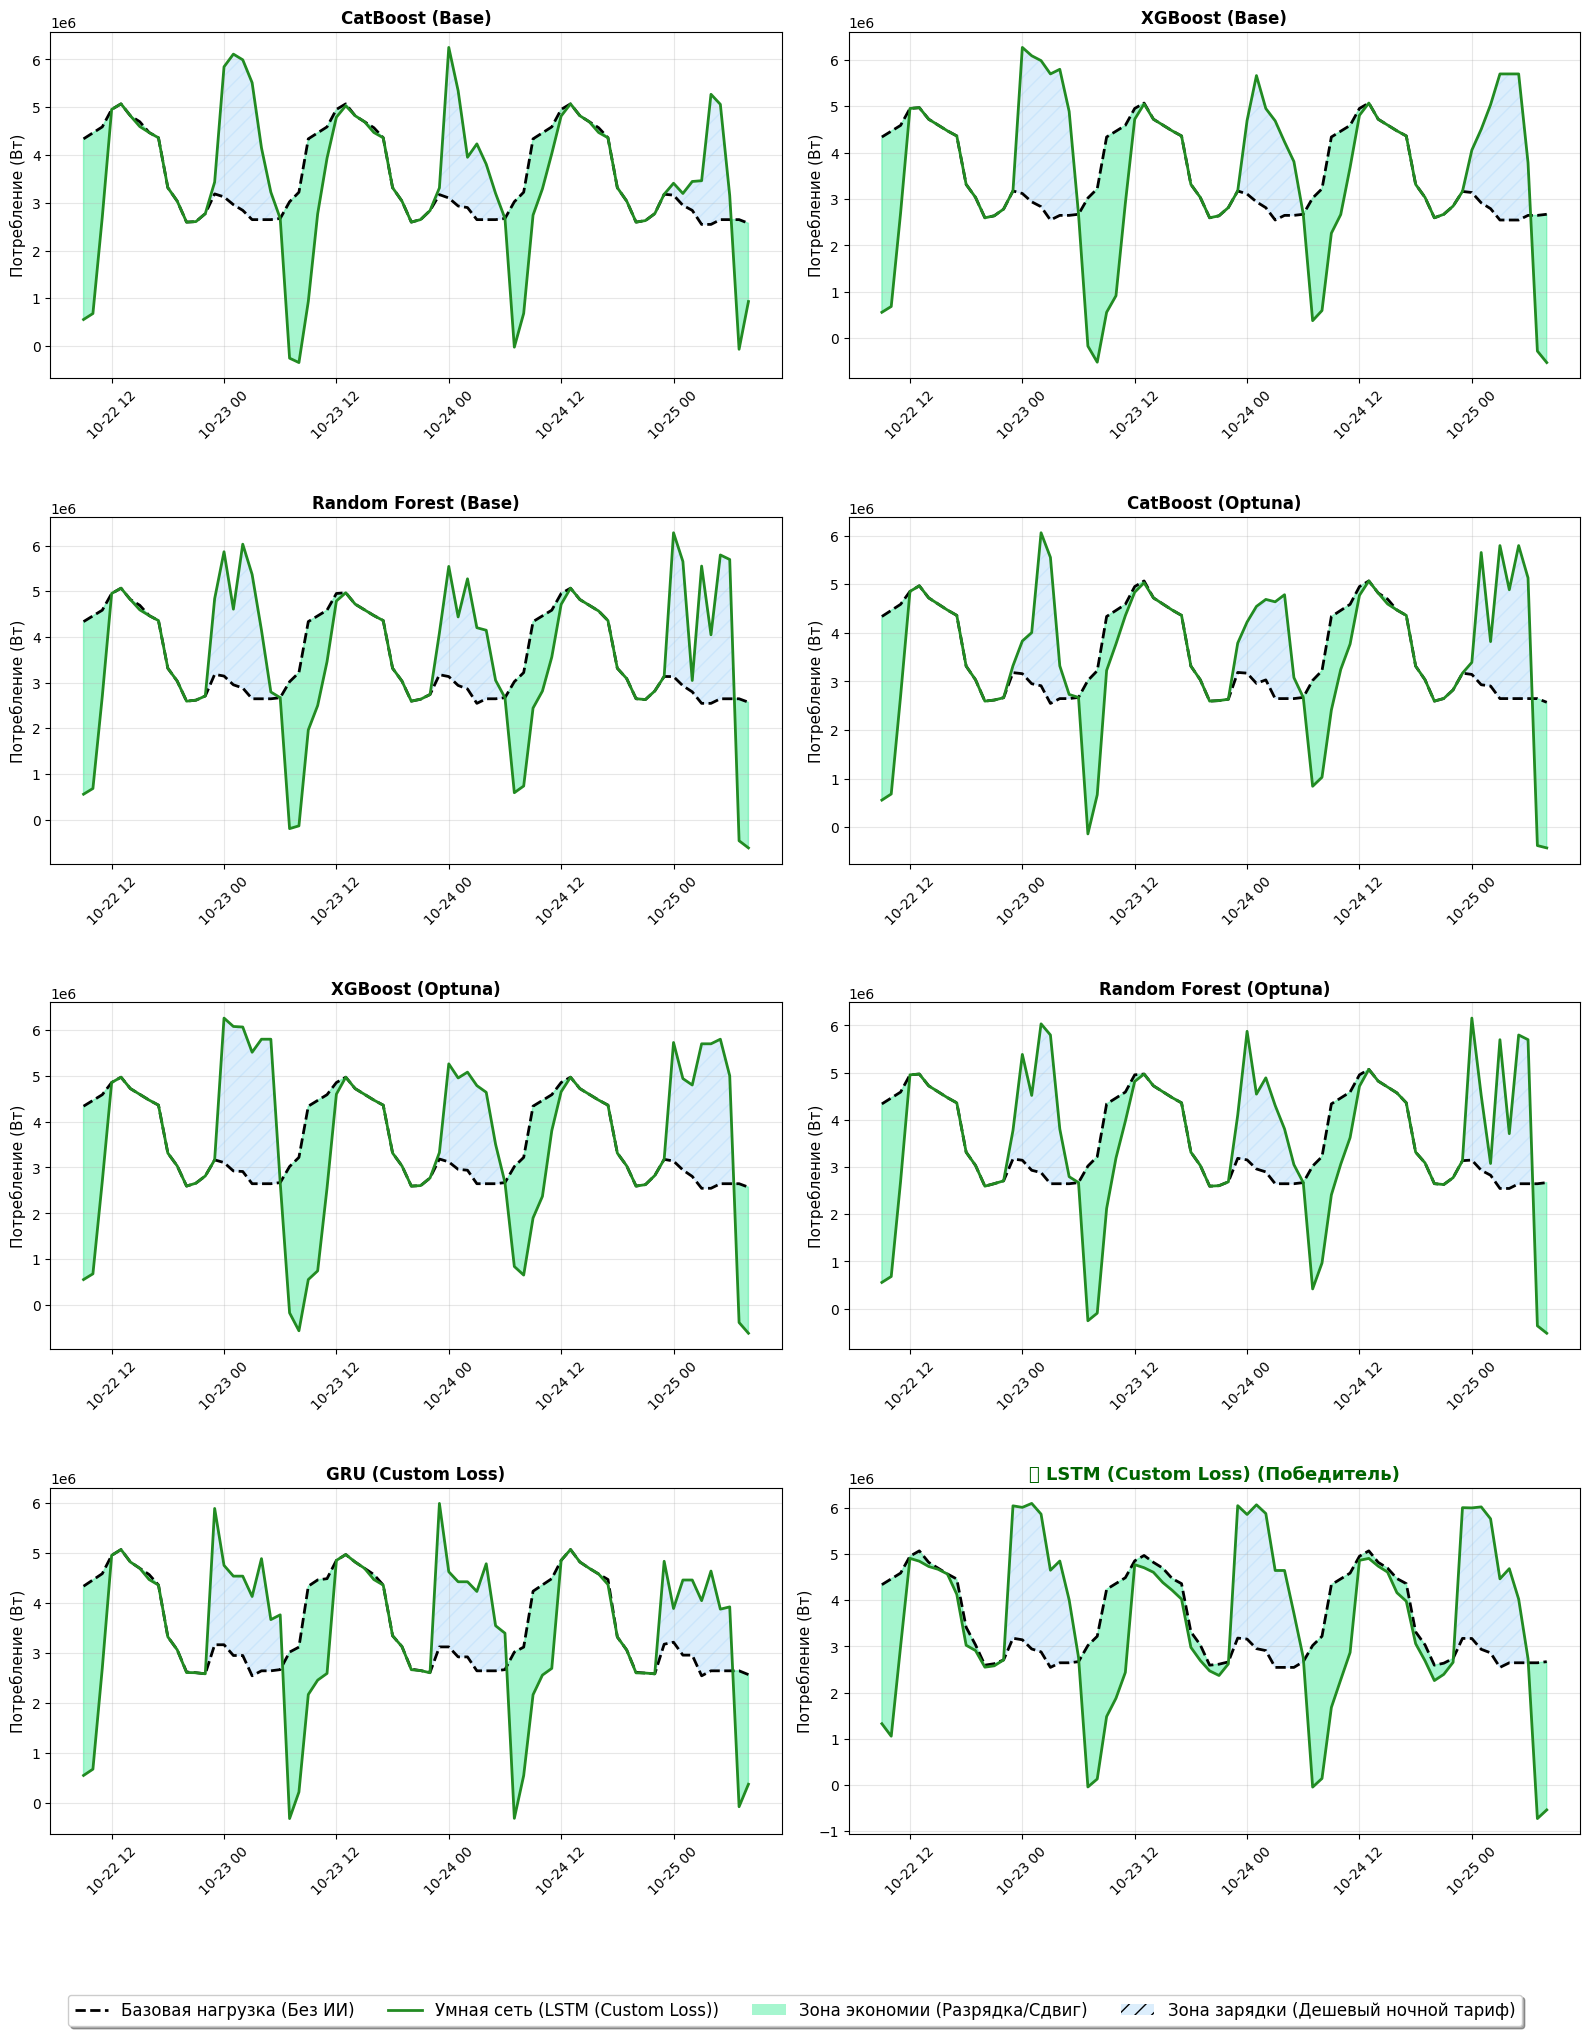

In [4]:
# ==============================================================================
# ЯЧЕЙКА 4: БИТВА МОДЕЛЕЙ И ВЫВОД РЕЗУЛЬТАТОВ
# ==============================================================================
import math
from matplotlib.patches import Patch

print("⏳ Создаем фиксированную популяцию агентов...")
GLOBAL_AGENTS = []
for i in range(60): GLOBAL_AGENTS.append(SmartHouseholdAgent(f"res_{i}", 'residential'))
for i in range(80): GLOBAL_AGENTS.append(SmartHouseholdAgent(f"com_{i}", 'commercial'))
for i in range(1):  GLOBAL_AGENTS.append(SmartHouseholdAgent(f"ind_{0}", 'industrial'))

all_sim_results = {}
results_summary = []

print("\n" + "="*80)
print(f"{'МОДЕЛЬ ИИ':<25} | {'БАЗОВАЯ ЦЕНА':<15} | {'УМНАЯ ЦЕНА':<15} | {'ЭКОНОМИЯ'} ")
print("="*80)

for name, preds in models_predictions.items():
    df_sim = run_simulation_fixed(name, preds, agents_list=GLOBAL_AGENTS, dates_array=dates_test, days=30)
    all_sim_results[name] = df_sim
    
    b_cost = df_sim['cost_base'].sum()
    s_cost = df_sim['cost_smart'].sum()
    profit = b_cost - s_cost
    percent = (profit / b_cost) * 100
    
    results_summary.append({'Model': name, 'Savings (%)': percent, 'Profit': profit})
    print(f"{name:<25} | {b_cost:,.0f} ₽".replace(',', ' ') + f" | {s_cost:,.0f} ₽".replace(',', ' ') + f" | 💰 {profit:,.0f} ₽ ({percent:.2f}%)".replace(',', ' '))

print("="*80)

# Находим лучшую модель
best_model = max(results_summary, key=lambda x: x['Savings (%)'])
print(f"🏆 АБСОЛЮТНЫЙ ПОБЕДИТЕЛЬ: {best_model['Model']} (Экономия {best_model['Savings (%)']:.2f}%)")

# ==============================================================================
# ВИЗУАЛИЗАЦИЯ ДЛЯ ВСЕХ МОДЕЛЕЙ (СЕТКА ГРАФИКОВ)
# ==============================================================================
num_models = len(all_sim_results)
cols = 2 if num_models > 1 else 1
rows = math.ceil(num_models / cols)

# Создаем фигуру нужного размера в зависимости от количества моделей
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
if num_models > 1:
    axes = axes.flatten()
else:
    axes = [axes]

vis_hours = 24 * 3 # Первые 3 дня для графика

for idx, (model_name, df_sim) in enumerate(all_sim_results.items()):
    ax = axes[idx]
    
    l1, = ax.plot(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], 
                   label='Базовая нагрузка (Без ИИ)', color='black', linestyle='--', linewidth=2)
    l2, = ax.plot(df_sim['timestamp'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                   label=f'Умная сеть ({model_name})', color='forestgreen', linewidth=2)

    # Полная закраска: Зона экономии (Разрядка/Сдвиг нагрузки)
    ax.fill_between(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                     where=(df_sim['smart_load'][:vis_hours] <= df_sim['base_load'][:vis_hours]), 
                     color='#00E676', alpha=0.35, interpolate=True)

    # Полная закраска: Зона потребления (Зарядка батарей ночью)
    ax.fill_between(df_sim['timestamp'][:vis_hours], df_sim['base_load'][:vis_hours], df_sim['smart_load'][:vis_hours], 
                     where=(df_sim['smart_load'][:vis_hours] > df_sim['base_load'][:vis_hours]), 
                     color='#BBDEFB', alpha=0.5, hatch='//', interpolate=True)

    # Подсветка заголовка для победителя
    if model_name == best_model['Model']:
        ax.set_title(f"🏆 {model_name} (Победитель)", fontsize=13, fontweight='bold', color='darkgreen')
    else:
        ax.set_title(f"{model_name}", fontsize=12, fontweight='bold')
        
    ax.set_ylabel('Потребление (Вт)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Удаляем пустые графики, если количество моделей нечетное
for idx in range(num_models, len(axes)):
    fig.delaxes(axes[idx])

# Единая легенда для всей фигуры
patch1 = Patch(facecolor='#00E676', alpha=0.35, label='Зона экономии (Разрядка/Сдвиг)')
patch2 = Patch(facecolor='#BBDEFB', alpha=0.5, hatch='//', label='Зона зарядки (Дешевый ночной тариф)')
lines = [l1, l2, patch1, patch2]
labels = [l.get_label() for l in lines]

fig.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
# Оставляем место внизу для глобальной легенды
plt.subplots_adjust(bottom=0.08 if rows > 1 else 0.15, hspace=0.4) 
plt.savefig('data/16_all_models_simulation.png', dpi=150, bbox_inches='tight')
plt.show()